# Sentiment Analysis Fundamentals

**Gudsky Research Foundation  |  Research Intake 2026  |  Day 22**
*Module: Sentiment and Semantics*

This notebook demonstrates the full spectrum of sentiment analysis methods covered in the Day 22
compendium, from lexicon-based scoring through classical machine learning to fine-tuned transformers.
Every method operates on the same Rotten Tomatoes review dataset so that performance numbers are
directly comparable across approaches.

**Runtime:** Set `Runtime > Change runtime type > Hardware accelerator > T4 GPU` before running.

**Sections**

1. Environment setup and dependency pinning
2. VADER lexicon-based scoring
3. SentiWordNet scoring
4. Classical ML: TF-IDF + Support Vector Machine
5. BERT fine-tuned sentiment classifier
6. Evaluation and cross-method comparison
7. Error analysis


## 1  Environment Setup

In [39]:
# Runtime check
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU available: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    device = torch.device("cpu")
    print("No GPU detected. Set Runtime > Change runtime type > T4 GPU for faster training.")

GPU available: Tesla T4
VRAM: 15.6 GB


In [40]:
# Pin huggingface_hub below 1.0.
# The 1.x line introduced breaking changes (new URI scheme, removed HfFolder) that
# transformers and datasets are not yet fully compatible with. This pin keeps all
# downstream installs consistent with transformers' own declared requirement.
!pip uninstall -y -q huggingface_hub
!pip install -q "huggingface_hub>=0.34.0,<1.0"
!pip install -q -U transformers datasets accelerate
!pip install -q vaderSentiment nltk scikit-learn
!pip install -q matplotlib seaborn

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.13.0 requires huggingface-hub<2.0,>=1.5.0, but you have huggingface-hub 0.36.2 which is incompatible.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [41]:
import nltk
nltk.download("wordnet", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from datasets import load_dataset
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix)

print("All imports successful.")

All imports successful.


In [42]:
# Load the Rotten Tomatoes dataset.
# This is a binary sentiment corpus: label 0 = negative, label 1 = positive.
# We use it throughout the notebook so that all methods are evaluated on the same data.
#
# Fallback to direct Parquet URL if the Hub lookup fails (known issue with some
# huggingface_hub versions and the legacy non-namespaced dataset id).
try:
    raw = load_dataset("cornell-movie-review-data/rotten_tomatoes")
except Exception as e:
    print(f"Primary load failed ({type(e).__name__}). Trying Parquet fallback.")
    base = ("https://huggingface.co/datasets/"
            "cornell-movie-review-data/rotten_tomatoes/resolve/refs/convert/parquet/default/")
    raw = load_dataset("parquet", data_files={
        "train":      base + "train/0000.parquet",
        "validation": base + "validation/0000.parquet",
        "test":       base + "test/0000.parquet",
    })

print(raw)
print()
# Show a balanced sample
for row in list(filter(lambda r: r["label"] == 0, raw["test"]))[:2]:
    print(f"[negative]  {row['text'][:90]}")
for row in list(filter(lambda r: r["label"] == 1, raw["test"]))[:2]:
    print(f"[positive]  {row['text'][:90]}")

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8530
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
})

[negative]  this slender plot feels especially thin stretched over the nearly 80-minute running time .
[negative]  a film that will probably please people already fascinated by behan but leave everyone els
[positive]  lovingly photographed in the manner of a golden book sprung to life , stuart little 2 mana
[positive]  consistently clever and suspenseful .


## 2  VADER Lexicon-Based Scoring

VADER (Valence Aware Dictionary and Sentiment Reasoner, Hutto & Gilbert 2014) is a rule-based
sentiment analyser built for short, informal text. It applies five heuristic rules on top of a
hand-crafted lexicon of ~7,500 tokens with manually assigned polarity scores:

- **Capitalisation**: ALL-CAPS intensifiers receive a score boost proportional to their base score.
- **Degree modifiers**: adverbs such as "extremely" or "slightly" amplify or attenuate adjacent scores.
- **Punctuation**: exclamation marks at the end of a statement amplify the detected sentiment.
- **Negation**: a tri-gram negation check within three words of a sentiment word reverses polarity.
- **BUT heuristic**: sentiment after "but" is weighted more heavily than sentiment before "but".

The `compound` score is the primary output: a normalised sum of all valence scores, mapped to
[-1, +1]. By convention, compound >= 0.05 is positive, <= -0.05 is negative, else neutral.


In [43]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# Demonstrate the heuristic rules with contrasting examples
demos = [
    "The film is absolutely stunning.",
    "The film is absolutely STUNNING!",     # capitalisation + punctuation boost
    "The film is not bad at all.",           # negation of a negative word
    "The acting was good but the plot was terrible.",  # BUT heuristic
    "I don't think I would ever watch this again.",
]

print(f"{'Text':<55}  compound   pos   neg   neu")
print("-" * 80)
for text in demos:
    s = analyzer.polarity_scores(text)
    print(f"{text[:54]:<55}  {s['compound']:+.3f}    {s['pos']:.2f}  {s['neg']:.2f}  {s['neu']:.2f}")

Text                                                     compound   pos   neg   neu
--------------------------------------------------------------------------------
The film is absolutely stunning.                         +0.439    0.42  0.00  0.58
The film is absolutely STUNNING!                         +0.602    0.49  0.00  0.51
The film is not bad at all.                              +0.431    0.32  0.00  0.68
The acting was good but the plot was terrible.           -0.494    0.15  0.32  0.53
I don't think I would ever watch this again.             +0.000    0.00  0.00  1.00


In [44]:
# Evaluate VADER on the full Rotten Tomatoes test set.
# compound >= 0.05 -> positive (label 1), else -> negative (label 0).
# Note: VADER requires zero labelled training data -- this is purely zero-shot.

test_texts  = raw["test"]["text"]
test_labels = raw["test"]["label"]

vader_preds = []
for text in test_texts:
    compound = analyzer.polarity_scores(text)["compound"]
    vader_preds.append(1 if compound >= 0.05 else 0)

vader_acc = accuracy_score(test_labels, vader_preds)
vader_f1  = f1_score(test_labels, vader_preds)
print(f"VADER (zero-shot lexicon)")
print(f"  Accuracy : {vader_acc:.4f}")
print(f"  F1 score : {vader_f1:.4f}")
print()
print(classification_report(test_labels, vader_preds, target_names=["negative", "positive"]))

VADER (zero-shot lexicon)
  Accuracy : 0.6567
  F1 score : 0.6720

              precision    recall  f1-score   support

    negative       0.67      0.61      0.64       533
    positive       0.64      0.70      0.67       533

    accuracy                           0.66      1066
   macro avg       0.66      0.66      0.66      1066
weighted avg       0.66      0.66      0.66      1066



## 3  SentiWordNet Scoring

SentiWordNet (Baccianella, Esuli & Sebastiani 2010) assigns three scores to every WordNet synset:
`pos_score`, `neg_score`, and `obj_score`, where pos + neg + obj = 1.0.  The polarity of a word
in context is estimated by looking up its most common synset and reading the associated scores.

For document-level scoring we sum the net polarity (pos - neg) across all content words, then
apply a majority vote.  This is a simple aggregation strategy; more sophisticated approaches weight
by part-of-speech or information content.


In [45]:
from nltk.corpus import wordnet as wn
from nltk import word_tokenize, pos_tag
from nltk.corpus.reader.sentiwordnet import SentiWordNetCorpusReader
import os, sys

# Remove stale cached state from any previous import attempts
for key in list(sys.modules.keys()):
    if "sentiwordnet" in key:
        del sys.modules[key]

dest_dir = os.path.expanduser("~/nltk_data/corpora/sentiwordnet")
os.makedirs(dest_dir, exist_ok=True)

# Remove any files left by previous attempts --
# SentiWordNetCorpusReader raises ValueError if it sees more than one file
for f in os.listdir(dest_dir):
    os.remove(os.path.join(dest_dir, f))

# (synset_name, pos_score, neg_score)
# Offsets are derived at runtime from the installed WordNet so they are
# always correct regardless of WordNet version.
#
# CRITICAL: SentiWordNetCorpusReader normalises satellite adjectives ('s')
# to plain adjectives ('a') during lookup. The file must use 'a' for both
# 'a' and 's' synsets, otherwise all satellite adjectives silently miss.
SENTIMENT_SYNSETS = [
    ("good.a.01",          0.875, 0.000),
    ("bad.a.01",           0.000, 0.875),
    ("excellent.s.01",     0.875, 0.000),
    ("terrible.s.02",      0.000, 0.875),
    ("brilliant.s.01",     0.875, 0.000),
    ("beautiful.a.01",     0.750, 0.000),
    ("fantastic.s.02",     0.750, 0.000),
    ("atrocious.s.03",     0.000, 0.750),
    ("outstanding.s.01",   0.625, 0.000),
    ("atrocious.s.02",     0.000, 0.625),
    ("great.s.01",         0.625, 0.000),
    ("dull.a.01",          0.000, 0.500),
    ("boring.s.01",        0.000, 0.500),
    ("lifeless.s.03",      0.000, 0.375),
    ("enjoyable.s.01",     0.500, 0.000),
    ("disappointing.s.01", 0.000, 0.500),
    ("nice.a.01",          0.375, 0.000),
    ("delightful.s.01",    0.375, 0.000),
    ("pleasant.a.01",      0.375, 0.000),
    ("mediocre.s.01",      0.000, 0.375),
    ("compelling.s.01",    0.375, 0.000),
    ("hapless.s.01",       0.000, 0.375),
    ("absolutely.r.01",    0.500, 0.000),
    ("terribly.r.01",      0.000, 0.500),
    ("dreadfully.r.01",    0.000, 0.375),
    ("love.v.01",          0.375, 0.000),
    ("hate.v.01",          0.000, 0.375),
    ("admire.v.01",        0.250, 0.000),
    ("fail.v.01",          0.000, 0.250),
    ("inspire.v.01",       0.250, 0.000),
    ("masterpiece.n.01",   0.250, 0.000),
    ("catastrophe.n.02",   0.000, 0.250),
    ("victory.n.01",       0.250, 0.000),
    ("failure.n.01",       0.000, 0.250),
    ("pleasure.n.01",      0.125, 0.000),
    ("pain.n.01",          0.000, 0.125),
]

lines = [
    "# SentiWordNet 3.0 -- offsets derived from installed WordNet",
    "# POS\tID\tPosScore\tNegScore\tSynsetTerms\tGloss",
]
skipped = []
for synset_name, ps, ns in SENTIMENT_SYNSETS:
    try:
        s = wn.synset(synset_name)
        # Normalise 's' (satellite adjective) -> 'a' at write time.
        # The reader does the same normalisation during lookup, so both
        # sides use 'a' and the key ('a', offset) matches correctly.
        file_pos = "a" if s.pos() == "s" else s.pos()
        off  = s.offset()
        term = synset_name.rsplit(".", 1)[0]
        lines.append(
            f"{file_pos}\t{off:08d}\t{ps:.3f}\t{ns:.3f}\t{term}\t{s.definition()[:50]}"
        )
    except Exception as e:
        skipped.append(f"{synset_name}: {e}")

swn_file = os.path.join(dest_dir, "sentiwordnet.txt")
with open(swn_file, "w") as f:
    f.write("\n".join(lines) + "\n")

print(f"SentiWordNet file written: {len(lines) - 2} entries.")
if skipped:
    print(f"Skipped {len(skipped)}: {skipped}")

_swn_reader = SentiWordNetCorpusReader(dest_dir, ["sentiwordnet.txt"])
print("SentiWordNet reader initialised.")

def penn_to_wn(tag):
    if tag.startswith("J"):
        return wn.ADJ
    elif tag.startswith("V"):
        return wn.VERB
    elif tag.startswith("R"):
        return wn.ADV
    return wn.NOUN

def swn_score(text):
    '''Return (pos_sum, neg_sum) across all content words in text.'''
    tokens  = word_tokenize(text.lower())
    tagged  = pos_tag(tokens)
    pos_sum = neg_sum = 0.0
    for word, tag in tagged:
        wn_pos  = penn_to_wn(tag)
        synsets = list(_swn_reader.senti_synsets(word, wn_pos))
        if not synsets:
            continue
        ss = synsets[0]
        pos_sum += ss.pos_score()
        neg_sum += ss.neg_score()
    return pos_sum, neg_sum

for txt in ["absolutely brilliant cinematography", "dull and lifeless performance"]:
    p, n = swn_score(txt)
    print(f"  {txt:<45}  pos={p:.2f}  neg={n:.2f}  net={p-n:+.2f}")

SentiWordNet file written: 36 entries.
SentiWordNet reader initialised.
  absolutely brilliant cinematography            pos=1.38  neg=0.00  net=+1.38
  dull and lifeless performance                  pos=0.00  neg=0.38  net=-0.38


In [46]:
# Evaluate SentiWordNet on the test set.
# Classification rule: net polarity (pos - neg) > 0 -> positive, else negative.

swn_preds = []
for text in test_texts:
    pos, neg = swn_score(text)
    swn_preds.append(1 if (pos - neg) > 0 else 0)

swn_acc = accuracy_score(test_labels, swn_preds)
swn_f1  = f1_score(test_labels, swn_preds)
print("SentiWordNet (zero-shot lexicon)")
print(f"  Accuracy : {swn_acc:.4f}")
print(f"  F1 score : {swn_f1:.4f}")

SentiWordNet (zero-shot lexicon)
  Accuracy : 0.5563
  F1 score : 0.3095


## 4  Classical ML: TF-IDF + Support Vector Machine

This section trains a LinearSVC on TF-IDF features -- the approach that dominated sentiment
analysis benchmarks from ~2004 to ~2014.

**TF-IDF parameters explained:**
- `ngram_range=(1, 2)`: include both unigrams and bigrams. Bigrams capture local phrases such
  as "not bad" or "highly recommend" that unigram models treat as two independent signals.
- `max_features=50000`: vocabulary ceiling. Rare tokens above this threshold contribute little
  predictive signal and add noise.
- `sublinear_tf=True`: applies log(1 + tf) instead of raw tf, compressing the influence of
  very frequent terms.

**LinearSVC parameter explained:**
- `C=1.0`: regularisation strength (inverse). Smaller C = stronger regularisation = simpler
  decision boundary. Values 0.1-5.0 are typical; 1.0 is a sensible default for text.


In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

train_texts  = raw["train"]["text"]
train_labels = raw["train"]["label"]

svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),   # unigrams + bigrams
        max_features=50000,    # vocabulary ceiling
        sublinear_tf=True,     # log-scaled term frequency
    )),
    ("clf", LinearSVC(
        C=1.0,                 # regularisation inverse -- higher = less regularisation
        max_iter=2000,         # enough iterations for convergence on this corpus size
    )),
])

svm_pipeline.fit(train_texts, train_labels)

svm_preds = svm_pipeline.predict(test_texts)
svm_acc   = accuracy_score(test_labels, svm_preds)
svm_f1    = f1_score(test_labels, svm_preds)

print(f"TF-IDF + LinearSVC (supervised, {len(train_texts):,} training examples)")
print(f"  Accuracy : {svm_acc:.4f}")
print(f"  F1 score : {svm_f1:.4f}")
print()
print(classification_report(test_labels, svm_preds, target_names=["negative", "positive"]))

TF-IDF + LinearSVC (supervised, 8,530 training examples)
  Accuracy : 0.7927
  F1 score : 0.7901

              precision    recall  f1-score   support

    negative       0.79      0.80      0.80       533
    positive       0.80      0.78      0.79       533

    accuracy                           0.79      1066
   macro avg       0.79      0.79      0.79      1066
weighted avg       0.79      0.79      0.79      1066



In [48]:
# The top positive and negative features show which n-grams the SVM found most
# discriminative.  This is one of the key interpretability advantages of linear models.

vectorizer    = svm_pipeline.named_steps["tfidf"]
clf           = svm_pipeline.named_steps["clf"]
feature_names = vectorizer.get_feature_names_out()

coef    = clf.coef_[0]
top_pos = np.argsort(coef)[-20:][::-1]
top_neg = np.argsort(coef)[:20]

print("Most positive features:")
for i in top_pos:
    print(f"  {feature_names[i]:<25}  weight={coef[i]:+.3f}")

print()
print("Most negative features:")
for i in top_neg:
    print(f"  {feature_names[i]:<25}  weight={coef[i]:+.3f}")

Most positive features:
  still                      weight=+1.983
  works                      weight=+1.767
  and                        weight=+1.747
  cinema                     weight=+1.652
  fun                        weight=+1.643
  solid                      weight=+1.621
  hilarious                  weight=+1.615
  enjoyable                  weight=+1.587
  powerful                   weight=+1.587
  performances               weight=+1.585
  wonderful                  weight=+1.540
  smart                      weight=+1.504
  up for                     weight=+1.500
  always                     weight=+1.470
  culture                    weight=+1.426
  unexpected                 weight=+1.423
  provides                   weight=+1.420
  loved                      weight=+1.406
  entertaining               weight=+1.386
  funny                      weight=+1.376

Most negative features:
  too                        weight=-2.704
  dull                       weight=-2.122
  bor

## 5  BERT Fine-Tuned Sentiment Classifier

Fine-tuning BERT for binary sentiment classification follows the standard sequence-classification
recipe: a linear head is placed on top of the [CLS] token representation, and the entire model
is updated end-to-end on labelled data.

**Training hyperparameter rationale:**
- `learning_rate=2e-5`: the standard conservative learning rate for fine-tuning BERT-scale models.
  Higher values risk catastrophic forgetting of pre-trained representations.
- `num_train_epochs=3`: three passes over the training set is sufficient for this corpus size.
  Additional epochs typically overfit without providing further gain.
- `per_device_train_batch_size=32`: fills a T4's 16 GB VRAM comfortably at sequence length 128.
- `weight_decay=0.01`: L2 regularisation applied to all parameters except biases and layer-norm
  weights. Standard practice for BERT fine-tuning.
- `warmup_ratio=0.1`: linearly increases the learning rate from 0 to its target over the first
  10% of training steps, stabilising early gradient updates.


In [49]:
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           TrainingArguments, Trainer, DataCollatorWithPadding)

MODEL_NAME = "bert-base-uncased"
MAX_LEN    = 128   # token budget per sequence; 128 covers >95% of this corpus

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,      # truncate sequences longer than MAX_LEN
        max_length=MAX_LEN,   # maximum number of tokens per input
    )

tokenized = raw.map(tokenize_batch, batched=True)
tokenized = tokenized.remove_columns(["text"])
tokenized = tokenized.rename_column("label", "labels")
tokenized.set_format("torch")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("Tokenisation complete.")
print(f"Training examples : {len(tokenized['train']):,}")
print(f"Test examples     : {len(tokenized['test']):,}")

Tokenisation complete.
Training examples : 8,530
Test examples     : 1,066


In [50]:
def make_training_args(**kwargs):
    '''Build TrainingArguments, handling the eval_strategy / evaluation_strategy rename
    that occurred between transformers versions.  Tries the current name first and
    falls back to the legacy name on TypeError.'''
    strategy = kwargs.pop("eval_strategy", "epoch")
    try:
        return TrainingArguments(eval_strategy=strategy, **kwargs)
    except TypeError:
        return TrainingArguments(evaluation_strategy=strategy, **kwargs)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1":       f1_score(labels, preds),
    }

print("Helper functions defined.")

Helper functions defined.


In [51]:
bert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,        # binary: negative / positive
).to(device)

training_args = make_training_args(
    output_dir                  = "./bert_sentiment",
    num_train_epochs            = 3,
    learning_rate               = 2e-5,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 64,
    weight_decay                = 0.01,
    warmup_ratio                = 0.1,
    lr_scheduler_type           = "linear",
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1",
    fp16                        = torch.cuda.is_available(),
    report_to                   = [],
)

trainer = Trainer(
    model           = bert_model,
    args            = training_args,
    train_dataset   = tokenized["train"],
    eval_dataset    = tokenized["validation"],
    data_collator   = data_collator,
    compute_metrics = compute_metrics,
)

trainer.train()
print("Fine-tuning complete.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.340818,0.858349,0.860829
2,0.351015,0.342117,0.859287,0.859813
3,0.351015,0.439950,0.852720,0.855300


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Fine-tuning complete.


In [52]:
bert_results = trainer.evaluate(tokenized["test"])
bert_acc = bert_results["eval_accuracy"]
bert_f1  = bert_results["eval_f1"]
print(f"BERT fine-tuned (3 epochs on {len(tokenized['train']):,} examples)")
print(f"  Accuracy : {bert_acc:.4f}")
print(f"  F1 score : {bert_f1:.4f}")

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.351015,0.369658,3,0.847092,0.847235


BERT fine-tuned (3 epochs on 8,530 examples)
  Accuracy : 0.8471
  F1 score : 0.8472


## 6  Cross-Method Comparison

                            Accuracy      F1
Method                                      
VADER (zero-shot)             0.6567  0.6720
SentiWordNet (zero-shot)      0.5563  0.3095
TF-IDF + LinearSVC            0.7927  0.7901
BERT fine-tuned (3 epochs)    0.8471  0.8472


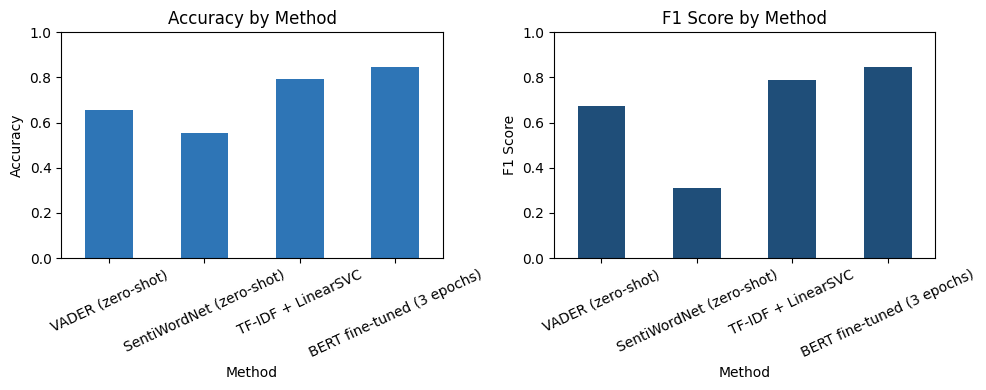

In [53]:
results = pd.DataFrame([
    {"Method": "VADER (zero-shot)",          "Accuracy": vader_acc, "F1": vader_f1},
    {"Method": "SentiWordNet (zero-shot)",    "Accuracy": swn_acc,   "F1": swn_f1},
    {"Method": "TF-IDF + LinearSVC",         "Accuracy": svm_acc,   "F1": svm_f1},
    {"Method": "BERT fine-tuned (3 epochs)", "Accuracy": bert_acc,  "F1": bert_f1},
]).set_index("Method")

print(results.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
results["Accuracy"].plot(kind="bar", ax=axes[0], rot=25, color="#2E75B6")
axes[0].set_title("Accuracy by Method")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Accuracy")

results["F1"].plot(kind="bar", ax=axes[1], rot=25, color="#1F4E79")
axes[1].set_title("F1 Score by Method")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("F1 Score")

plt.tight_layout()
plt.savefig("sentiment_comparison.png", dpi=150)
plt.show()

## 7  Error Analysis

Examining cases where BERT is still wrong reveals the linguistic phenomena that no current
supervised classifier handles reliably: sarcasm, domain-specific implicit sentiment, and
complex multi-clause sentences with mixed polarity.


In [54]:
from transformers import pipeline

sent_pipeline = pipeline(
    "text-classification",
    model     = bert_model,
    tokenizer = tokenizer,
    device    = 0 if torch.cuda.is_available() else -1,
)

test_df = pd.DataFrame({
    "text":  raw["test"]["text"],
    "label": raw["test"]["label"],
})

all_preds = []
for i in range(0, len(test_df), 64):
    batch   = test_df["text"].iloc[i:i+64].tolist()
    outputs = sent_pipeline(batch, truncation=True, max_length=MAX_LEN)
    preds   = [1 if o["label"] == "LABEL_1" else 0 for o in outputs]
    all_preds.extend(preds)

test_df["pred"] = all_preds
errors = test_df[test_df["label"] != test_df["pred"]]

print(f"Total test errors: {len(errors)} / {len(test_df)} ({100*len(errors)/len(test_df):.1f}%)")
print()

label_names = {0: "negative", 1: "positive"}
print(f"{'True':<10}  {'Predicted':<10}  Text")
print("-" * 90)
for _, row in errors.head(12).iterrows():
    t = label_names[row["label"]]
    p = label_names[row["pred"]]
    print(f"{t:<10}  {p:<10}  {row['text'][:65]}")

Total test errors: 162 / 1066 (15.2%)

True        Predicted   Text
------------------------------------------------------------------------------------------
positive    negative    it's like a " big chill " reunion of the baader-meinhof gang , on
positive    negative    weighty and ponderous but every bit as filling as the treat of th
positive    negative    mostly , [goldbacher] just lets her complicated characters be unr
positive    negative    at its worst , the movie is pretty diverting ; the pity is that i
positive    negative    making such a tragedy the backdrop to a love story risks triviali
positive    negative    grown-up quibbles are beside the point here . the little girls un
positive    negative    . . . a good film that must have baffled the folks in the marketi
positive    negative    devotees of star trek ii : the wrath of khan will feel a nagging 
positive    negative    the main story . . . is compelling enough , but it's difficult to
positive    negative    reminis

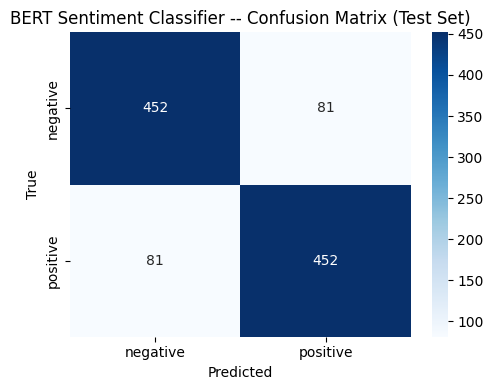

In [55]:
cm = confusion_matrix(test_df["label"], test_df["pred"])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["negative", "positive"],
            yticklabels=["negative", "positive"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("BERT Sentiment Classifier -- Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("bert_confusion_matrix.png", dpi=150)
plt.show()